<a href="https://colab.research.google.com/github/amhawary/big_data_project/blob/main/big_data_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Big Data Project
Authors: Amin Alhawary, Cinimol Mohseenali, Htoo Aung

# 1. Data Loading, Cleaning and Preparation


In [ ]:
import pandas as pd

In [ ]:
# -- if running the code on google colab, make sure you have the files in your drive then uncomment this:
from google.colab import drive
import os

drive.mount('/content/drive')

directory = "/content/drive/MyDrive/big_data_dir"

df_1 = pd.read_csv(os.path.join(directory,'Dataset-AAKTP-Node 1 Baby chick section.csv'))
df_2 = pd.read_csv(os.path.join(directory,'Dataset-AAKTP-Node 2 Main-East-Zone.csv'))
df_3 = pd.read_csv(os.path.join(directory,'Dataset-AAKTP-Node 3 Main West-Zone.csv'))

# -- if running the code locally, uncomment this:
# df_1 = pd.read_csv('Dataset-AAKTP-Node 1 Baby chick section.csv')
# df_2 = pd.read_csv('Dataset-AAKTP-Node 2 Main-East-Zone.csv')
# df_3 = pd.read_csv('Dataset-AAKTP-Node 3 Main West-Zone.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(df_1.shape)
display(df_1.head(5))

(85984, 12)


,Time,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC
0,01/02/2024 21:22,23,45,50,77,407,1,106,3,7,7,102
1,02/02/2024 9:05,13,69,49,119,4,0,59,4,90,93,98
2,02/02/2024 9:10,13,69,46,49,3,0,59,3,3,3,102
3,02/02/2024 9:15,13,68,46,50,10,0,59,2,0,0,99
4,02/02/2024 9:20,13,68,46,48,13,0,58,2,0,0,100


In [ ]:
print(df_2.shape)
display(df_2.head(5))

(80987, 12)


,Time,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC
0,01/02/2024 21:31,23,44,53,498,328,0,105,4,8,8,102
1,02/02/2024 10:43,19,56,60,111,704,0,73,3,0,0,102
2,02/02/2024 10:48,19,55,53,87,664,0,71,3,0,0,101
3,02/02/2024 10:53,19,55,51,80,700,0,68,3,1,1,100
4,02/02/2024 10:58,19,54,55,350,703,0,65,3,21,21,100


In [ ]:
print(df_3.shape)
display(df_3.head(5))

(87127, 12)


,Time,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC
0,07/02/2024 13:55,25,29,211,494,701,1,37,2,2,2,114
1,07/02/2024 15:18,23,31,211,479,459,0,34,2,4,4,85
2,07/02/2024 15:26,24,30,210,473,631,0,34,2,3,3,95
3,07/02/2024 15:51,25,30,231,493,648,0,33,2,4,4,101
4,07/02/2024 15:56,25,29,236,482,612,0,33,2,4,4,106


In [ ]:
# Setup for shared data quality checks
import numpy as np


datasets = {
    "Node 1 - Baby chick": df_1.copy(),
    "Node 2 - Main East": df_2.copy(),
    "Node 3 - Main West": df_3.copy(),
}

for name, df in datasets.items():
    # Normalise headers to avoid hidden mismatches from extra spaces
    df.columns = [c.strip() for c in df.columns]
    datasets[name] = df

print("Datasets ready:")
for name, df in datasets.items():
    print(f"- {name}: {df.shape[0]} rows, {df.shape[1]} columns")

Datasets ready:
- Node 1 - Baby chick: 85984 rows, 12 columns
- Node 2 - Main East: 80987 rows, 12 columns
- Node 3 - Main West: 87127 rows, 12 columns


In [ ]:
# 1) Assert all columns match names and dtypes across all three datasets
reference_name = list(datasets.keys())[0]
reference_df = datasets[reference_name]
reference_cols = list(reference_df.columns)
reference_dtypes = reference_df.dtypes.astype(str)

print(f"Reference dataset: {reference_name}\n")

for name, df in datasets.items():
    col_match = list(df.columns) == reference_cols
    dtype_compare = pd.DataFrame({
        "reference_dtype": reference_dtypes,
        "current_dtype": df.dtypes.astype(str)
    })
    dtype_compare["dtype_match"] = dtype_compare["reference_dtype"] == dtype_compare["current_dtype"]

    print(f"=== {name} ===")
    print(f"Column order/name match: {col_match}")

    if not col_match:
        missing = sorted(set(reference_cols) - set(df.columns))
        extra = sorted(set(df.columns) - set(reference_cols))
        print("Missing columns:", missing)
        print("Extra columns:", extra)

    if not dtype_compare["dtype_match"].all():
        print("Dtype mismatches:")
        display(dtype_compare[~dtype_compare["dtype_match"]])
    else:
        print("All dtypes match reference.")
    print()

Reference dataset: Node 1 - Baby chick

=== Node 1 - Baby chick ===
Column order/name match: True
All dtypes match reference.

=== Node 2 - Main East ===
Column order/name match: True
All dtypes match reference.

=== Node 3 - Main West ===
Column order/name match: True
All dtypes match reference.



In [ ]:
# 2) Check NaNs in numeric columns and empty/missing strings in non-numeric columns
for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    other_cols = [c for c in df.columns if c not in numeric_cols]

    numeric_nan_counts = df[numeric_cols].isna().sum().sort_values(ascending=False)

    text_missing_counts = {}
    for col in other_cols:
        series = df[col]
        text_missing_counts[col] = (
            series.isna() |
            series.astype(str).str.strip().eq("") |
            series.astype(str).str.strip().str.lower().isin(["nan", "none", "null", "na", "n/a"])
        ).sum()

    print(f"=== {name} ===")
    print("Numeric NaN counts:")
    display(numeric_nan_counts.to_frame("nan_count"))

    print("Non-numeric missing/empty counts:")
    display(pd.Series(text_missing_counts, name="missing_or_empty_count").to_frame())
    print()

=== Node 1 - Baby chick ===
Numeric NaN counts:


,nan_count
Temperature,0
Humidity,0
Noise-Avg,0
Noise-Peak,0
Light,0
H2S,0
NH3,0
NO2,0
PM2-5,0
PM10,0


Non-numeric missing/empty counts:


,missing_or_empty_count
Time,0



=== Node 2 - Main East ===
Numeric NaN counts:


...

,missing_or_empty_count
Time,0



=== Node 3 - Main West ===
Numeric NaN counts:


,nan_count
Temperature,0
Humidity,0
Noise-Avg,0
Noise-Peak,0
Light,0
H2S,0
NH3,0
NO2,0
PM2-5,0
PM10,0


Non-numeric missing/empty counts:


,missing_or_empty_count
Time,0


There are no missing or empty counts initially.

=== Node 1 - Baby chick ===


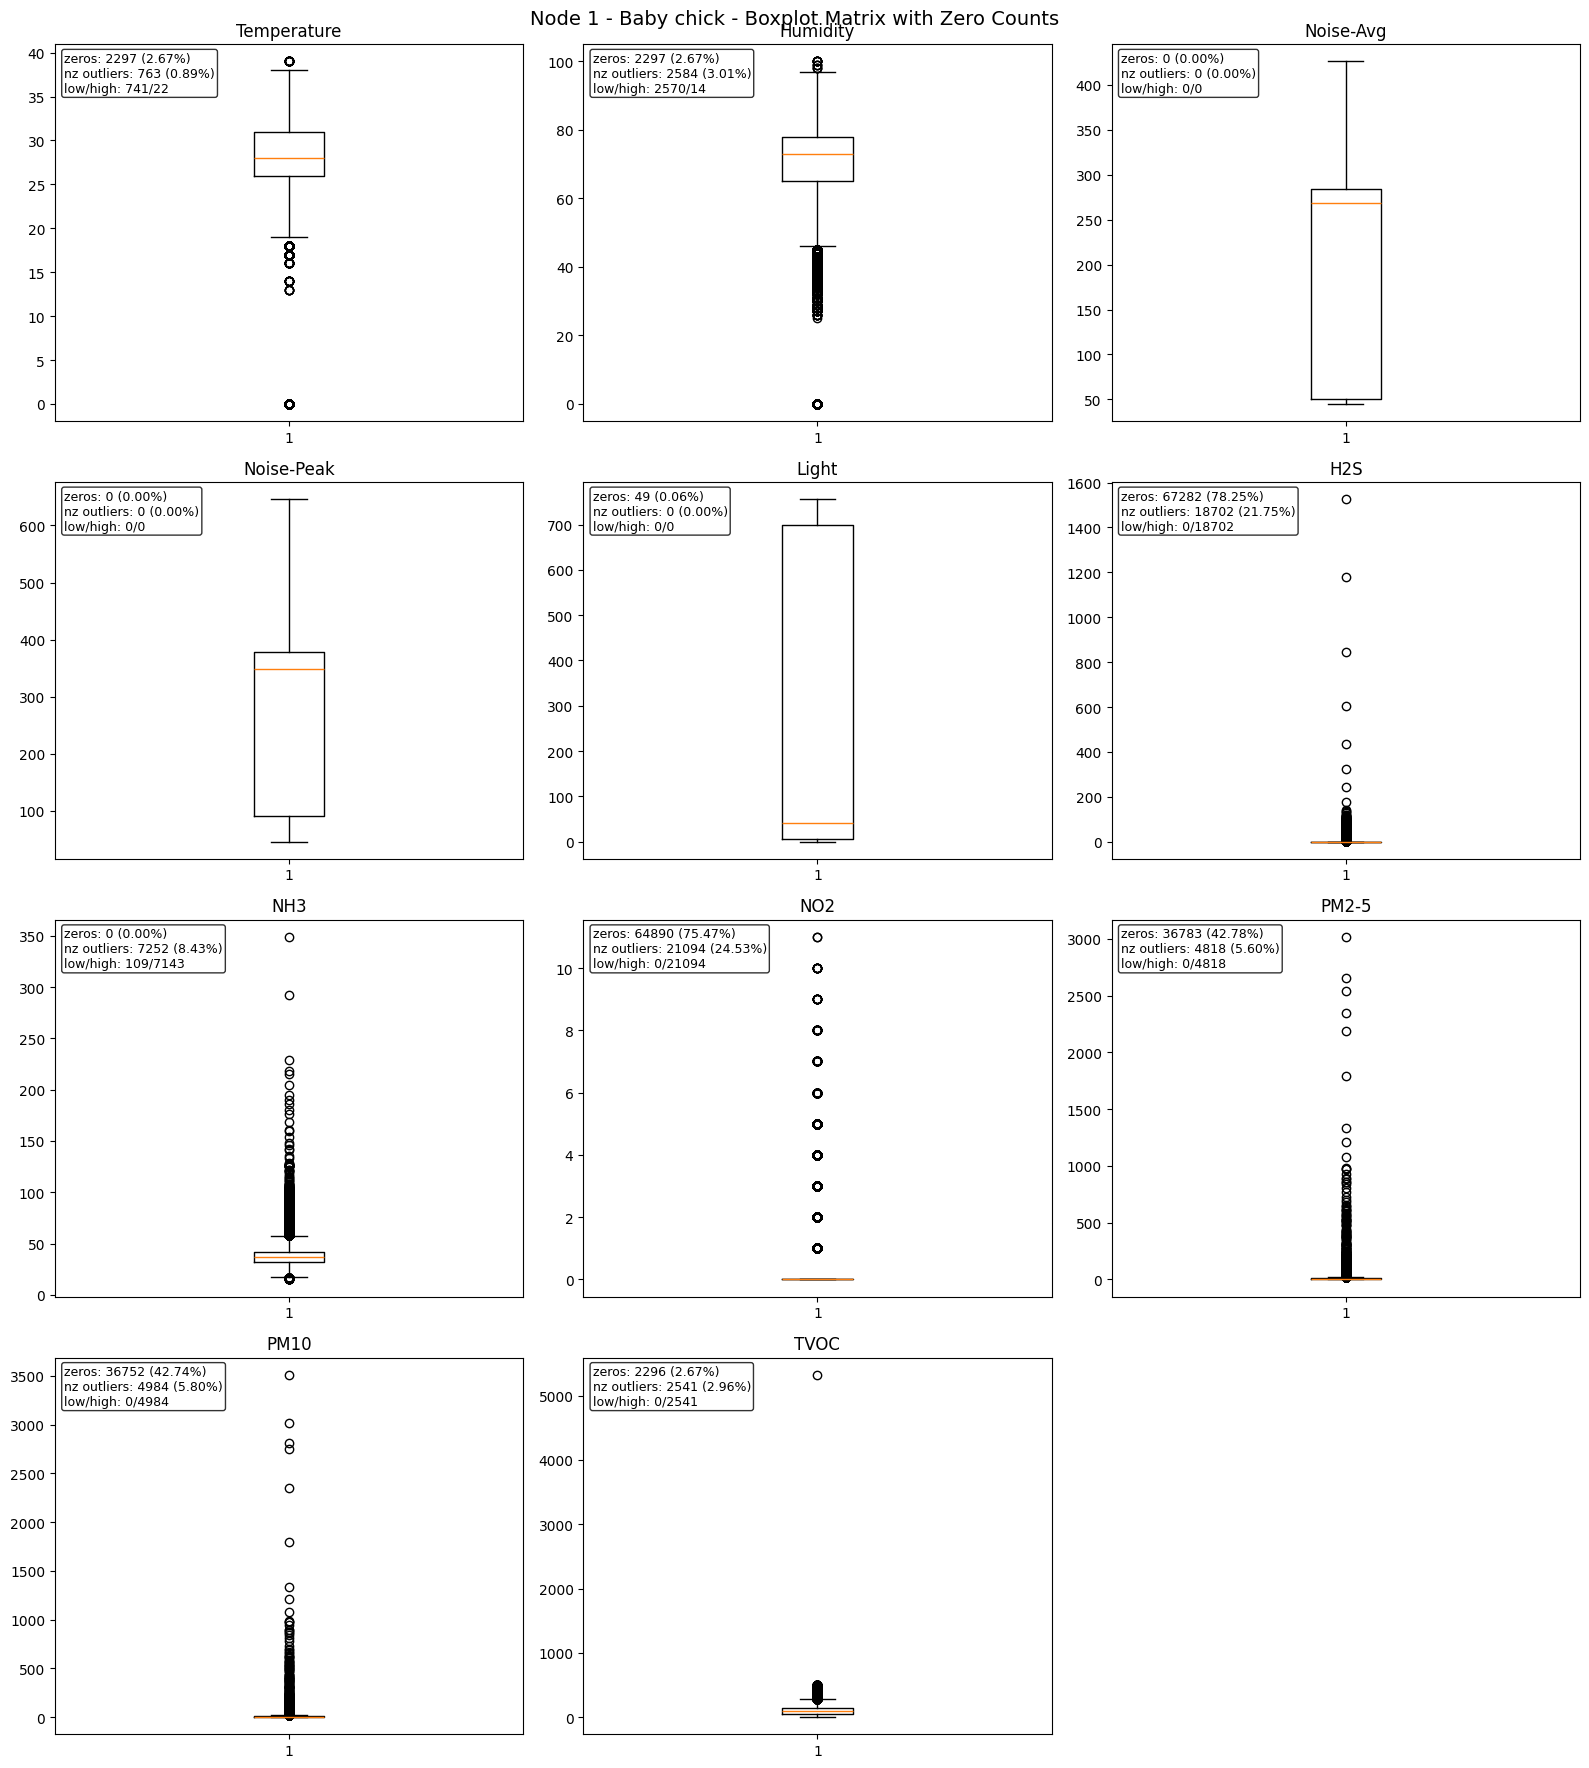

,column,outlier_count,outlier_pct,zero_count,zero_pct,lower_iqr_bound,upper_iqr_bound
7,NO2,21094,24.53,64890,75.47,0.0,0.0
5,H2S,18702,21.75,67282,78.25,0.0,0.0
6,NH3,7252,8.43,0,0.00,17.0,57.0
9,PM10,4984,5.80,36752,42.74,-13.5,22.5
1,Humidity,4881,5.68,2297,2.67,45.5,97.5
8,PM2-5,4818,5.60,36783,42.78,-13.5,22.5
0,Temperature,3060,3.56,2297,2.67,18.5,38.5
10,TVOC,2541,2.96,2296,2.67,-83.5,288.5
4,Light,0,0.00,49,0.06,-1032.0,1736.0
2,Noise-Avg,0,0.00,0,0.00,-298.5,633.5



=== Node 2 - Main East ===


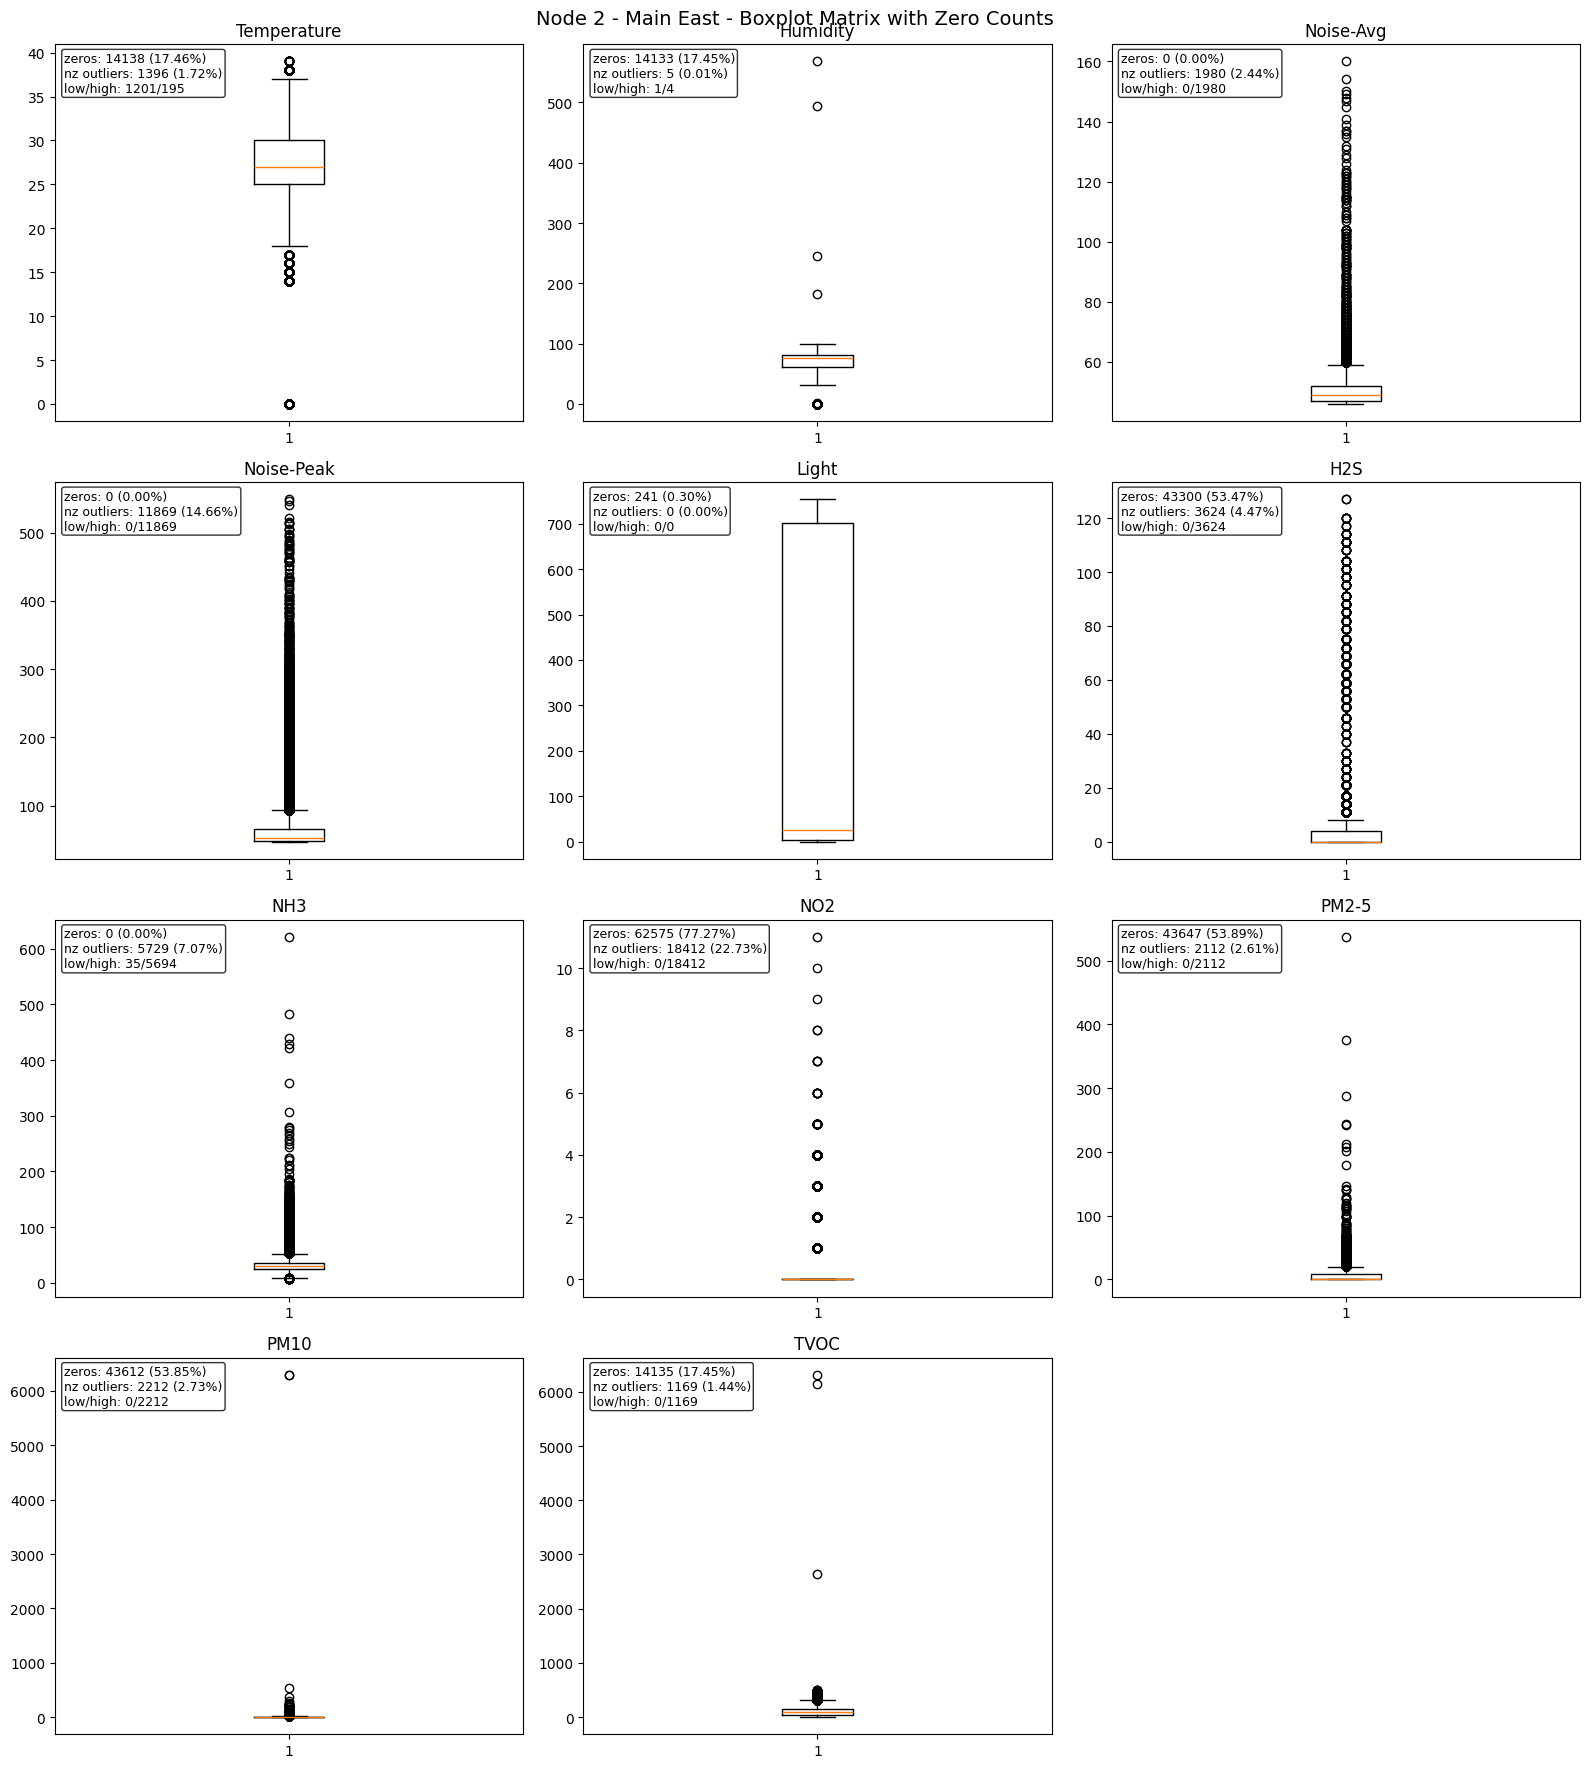

,column,outlier_count,outlier_pct,zero_count,zero_pct,lower_iqr_bound,upper_iqr_bound
7,NO2,18412,22.73,62575,77.27,0.0,0.0
0,Temperature,15534,19.18,14138,17.46,17.5,37.5
1,Humidity,14138,17.46,14133,17.45,31.0,111.0
3,Noise-Peak,11869,14.66,0,0.00,21.0,93.0
6,NH3,5729,7.07,0,0.00,8.5,52.5
5,H2S,3624,4.47,43300,53.47,-6.0,10.0
9,PM10,2212,2.73,43612,53.85,-12.0,20.0
8,PM2-5,2112,2.61,43647,53.89,-12.0,20.0
2,Noise-Avg,1980,2.44,0,0.00,39.5,59.5
10,TVOC,1169,1.44,14135,17.45,-120.5,315.5



=== Node 3 - Main West ===


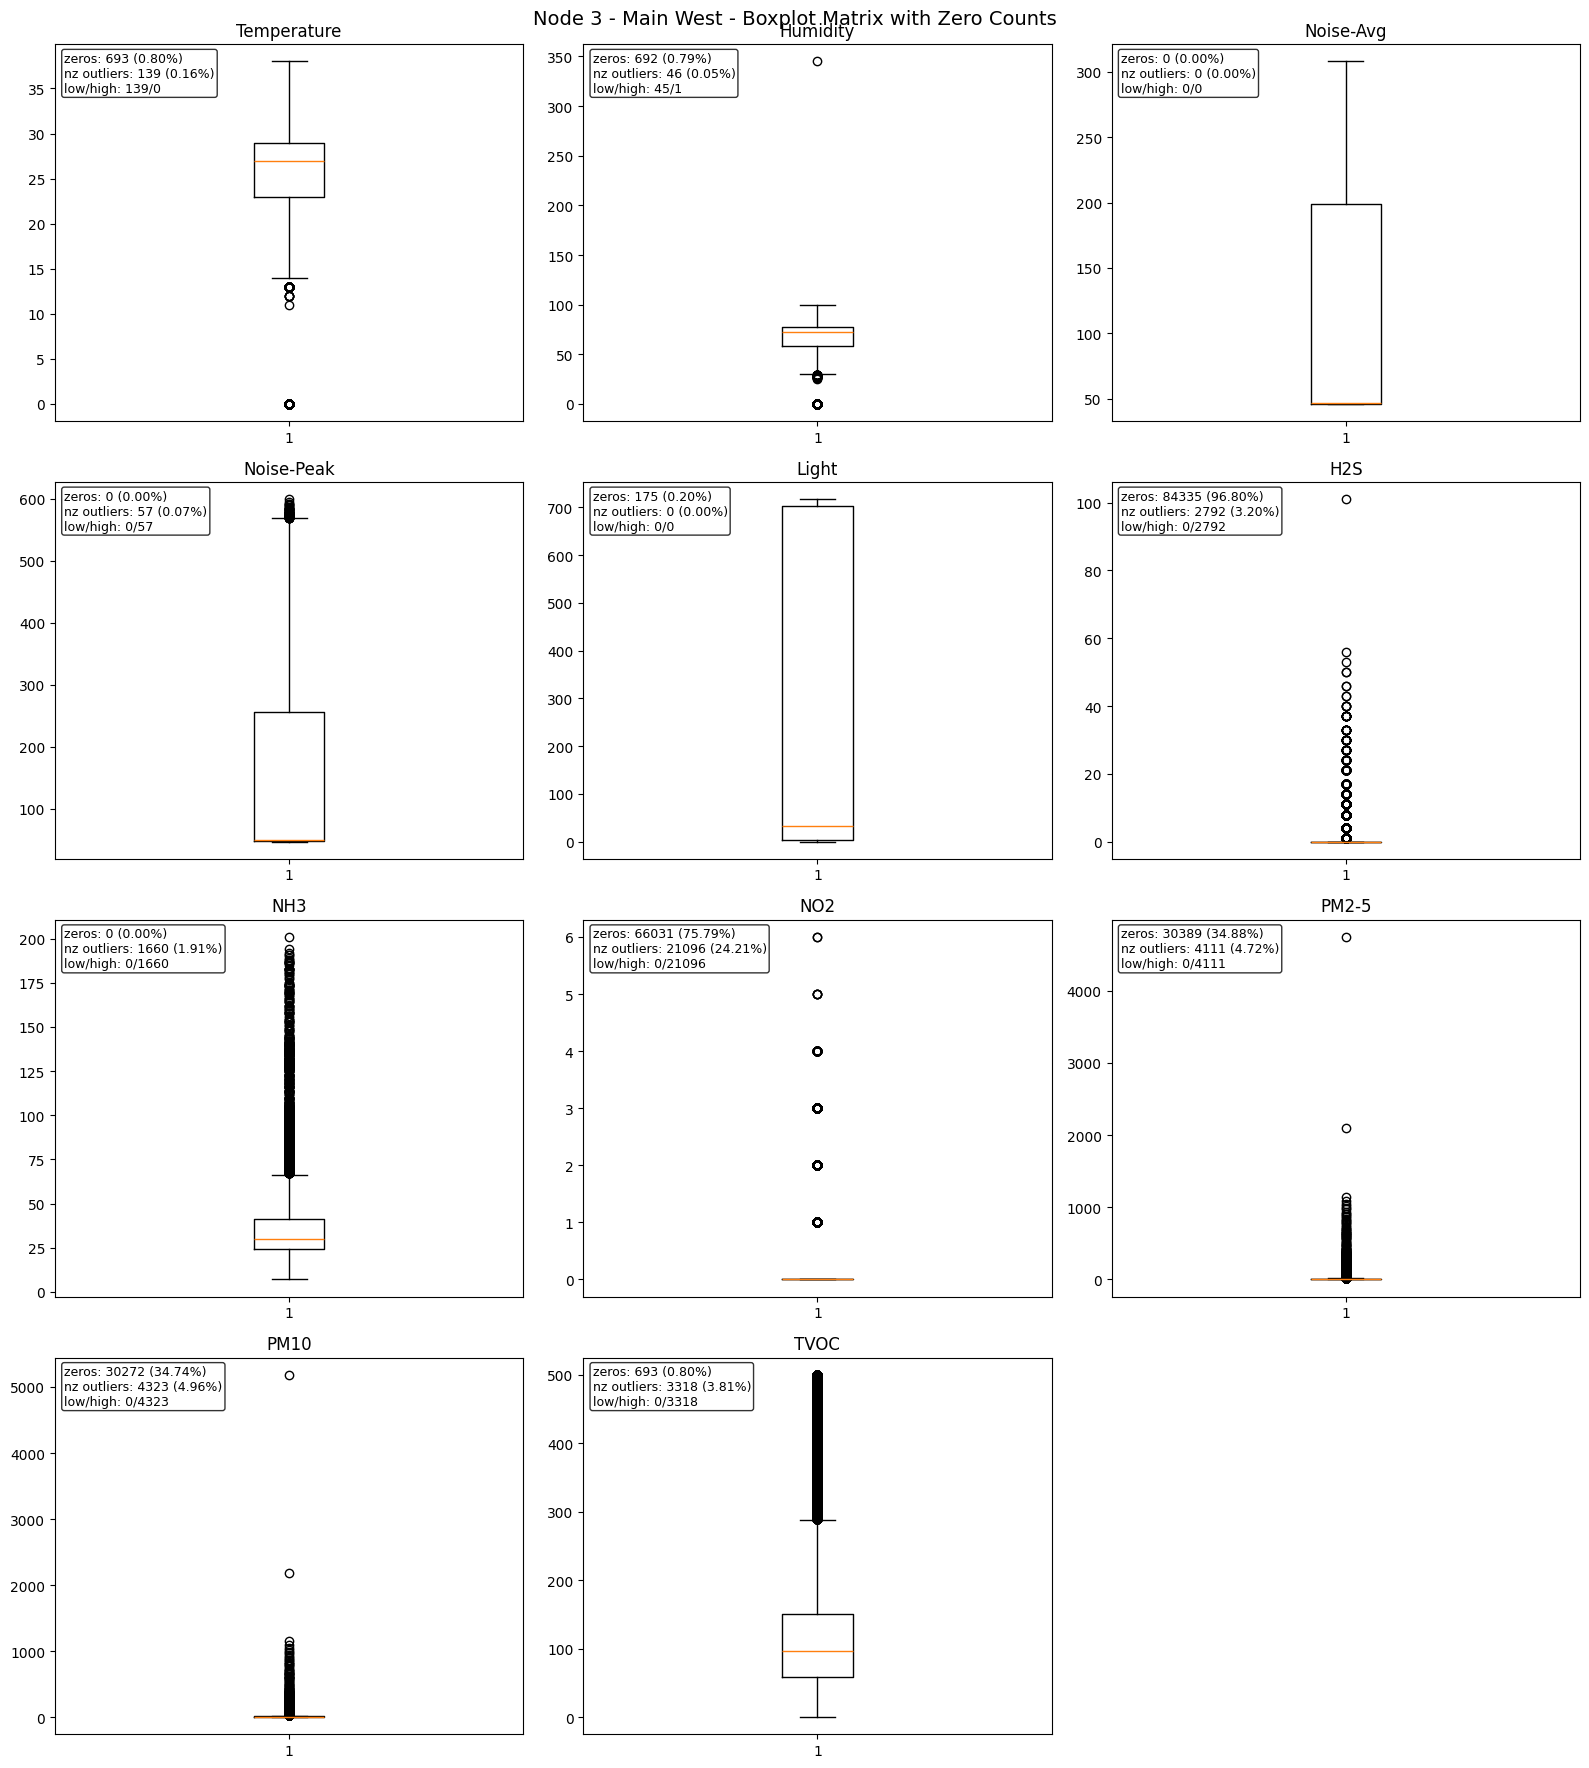

,column,outlier_count,outlier_pct,zero_count,zero_pct,lower_iqr_bound,upper_iqr_bound
7,NO2,21096,24.21,66031,75.79,0.0,0.0
9,PM10,4323,4.96,30272,34.74,-15.0,25.0
8,PM2-5,4111,4.72,30389,34.88,-15.0,25.0
10,TVOC,3318,3.81,693,0.80,-80.0,288.0
5,H2S,2792,3.20,84335,96.80,0.0,0.0
6,NH3,1660,1.91,0,0.00,-1.5,66.5
0,Temperature,832,0.95,693,0.80,14.0,38.0
1,Humidity,738,0.85,692,0.79,29.5,105.5
3,Noise-Peak,57,0.07,0,0.00,-264.0,568.0
4,Light,0,0.00,175,0.20,-1043.0,1749.0


In [ ]:
# 3) Outlier check per numeric column + zero-value review
# We will decide later which zeros are invalid and convert those to NaN.
import matplotlib.pyplot as plt


def iqr_outlier_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper


for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    rows = []
    for col in numeric_cols:
        s = df[col].dropna()
        if s.empty:
            rows.append({
                "column": col,
                "outlier_count": 0,
                "outlier_pct": 0.0,
                "zero_count": 0,
                "zero_pct": 0.0,
                "lower_iqr_bound": np.nan,
                "upper_iqr_bound": np.nan,
            })
            continue

        outlier_mask, lower, upper = iqr_outlier_mask(s)
        outlier_count = int(outlier_mask.sum())
        zero_count = int((s == 0).sum())

        rows.append({
            "column": col,
            "outlier_count": outlier_count,
            "outlier_pct": round((outlier_count / len(s)) * 100, 2),
            "zero_count": zero_count,
            "zero_pct": round((zero_count / len(s)) * 100, 2),
            "lower_iqr_bound": round(lower, 3),
            "upper_iqr_bound": round(upper, 3),
        })

    outlier_report = pd.DataFrame(rows).sort_values(["outlier_count", "zero_count"], ascending=False)

    print(f"=== {name} ===")

    # Boxplot matrix (before tabular outlier report)
    n_cols = len(numeric_cols)
    n_plot_cols = 3
    n_plot_rows = int(np.ceil(n_cols / n_plot_cols))

    fig, axes = plt.subplots(n_plot_rows, n_plot_cols, figsize=(16, 4.5 * n_plot_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        s = df[col].dropna()
        if s.empty:
            ax.set_title(f"{col}\n(no valid values)")
            ax.axis("off")
            continue

        ax.boxplot(s.values, vert=True)
        zero_count = int((s == 0).sum())
        zero_pct = (zero_count / len(s)) * 100

        outlier_mask, lower, upper = iqr_outlier_mask(s)
        non_zero_outlier_mask = outlier_mask & (s != 0)
        low_non_zero_outliers = int(((s < lower) & (s != 0)).sum())
        high_non_zero_outliers = int(((s > upper) & (s != 0)).sum())
        non_zero_outlier_count = int(non_zero_outlier_mask.sum())
        non_zero_outlier_pct = (non_zero_outlier_count / len(s)) * 100

        ax.set_title(col)
        ax.text(
            0.02,
            0.98,
            (
                f"zeros: {zero_count} ({zero_pct:.2f}%)\n"
                f"nz outliers: {non_zero_outlier_count} ({non_zero_outlier_pct:.2f}%)\n"
                f"low/high: {low_non_zero_outliers}/{high_non_zero_outliers}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
        )

    # Hide any unused subplot axes
    for j in range(n_cols, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{name} - Boxplot Matrix with Zero Counts", fontsize=14)
    plt.tight_layout()
    plt.show()

    display(outlier_report)
    print()

At this stage, we will remove extreme outliers as that look like clear misinput/invalid entries. As for other anomolies and patterns, this can be detected later on.


| Column | Node 1 | Node 2 | Node 3 |
|------|-----|------------|------|
| NO2 | x | x | x |
| PM10 | x | x | x |
| PM2-5 | x | x | x |
| TVOC | x | x | x |
| H2S | x | x | x |
| NH3 | x | x | x |
| Temperature |Zeros (2.5%) seem to be outliers | Zeros (17.46%) seem to be outliers | Zeros (0.8%) seem to be outliers |
| Humidty |Zeros (2.5%) seem to be outliers | Zeros (17.46%) seem to be outliers | Zeros (0.8%) seem to be outliers |Zeros () seem to be outliers |
| Noise-Peak | x | x | x |
| Light | x | x | x |
| Noise-Avg | x | x | x |

In [ ]:
zero_as_missing_cols = ["Temperature", "Humidity"]

for name, df in datasets.items():
    for col in zero_as_missing_cols:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            df.loc[df[col] == 0, col] = np.nan

print("Applied zero->NaN conversion for columns:", zero_as_missing_cols)
print("(Leave list empty until you finalize zero-misinput decisions.)")

Applied zero->NaN conversion for columns: ['Temperature', 'Humidity']
(Leave list empty until you finalize zero-misinput decisions.)


In [ ]:
# 5b) Partial missingness with explicit missing columns and percentages
# Use this in place of the previous partial-missing breakdown.
for name, df in datasets.items():
    missing_counts = df.isna().sum(axis=1)
    partial_mask = (missing_counts >= 1) & (missing_counts < df.shape[1])
    partial_df = df.loc[partial_mask]

    total_rows = len(df)
    partial_rows = len(partial_df)

    print(f"=== {name} ===")
    print(f"Rows with partial missing values: {partial_rows} / {total_rows} ({(partial_rows / total_rows) * 100:.2f}%)")

    if partial_rows == 0:
        print("No partially-missing rows.")
    else:
        pattern_series = partial_df.isna().apply(
            lambda r: tuple(col for col, is_missing in r.items() if is_missing),
            axis=1,
        )

        pattern_breakdown = pattern_series.value_counts().rename_axis("missing_columns").reset_index(name="row_count")
        pattern_breakdown["missing_columns"] = pattern_breakdown["missing_columns"].apply(lambda cols: ", ".join(cols))
        pattern_breakdown["missing_values_in_pattern"] = pattern_breakdown["missing_columns"].str.count(",") + 1
        pattern_breakdown["pct_of_total_rows"] = (pattern_breakdown["row_count"] / total_rows * 100).round(2)
        pattern_breakdown["pct_of_partial_rows"] = (pattern_breakdown["row_count"] / partial_rows * 100).round(2)

        display(
            pattern_breakdown[
                [
                    "missing_columns",
                    "missing_values_in_pattern",
                    "row_count",
                    "pct_of_total_rows",
                    "pct_of_partial_rows",
                ]
            ]
        )

    print()

=== Node 1 - Baby chick ===
Rows with partial missing values: 2297 / 85984 (2.67%)


,missing_columns,missing_values_in_pattern,row_count,pct_of_total_rows,pct_of_partial_rows
0,"Temperature, Humidity",2,2297,2.67,100.0



=== Node 2 - Main East ===
Rows with partial missing values: 14138 / 80987 (17.46%)


,missing_columns,missing_values_in_pattern,row_count,pct_of_total_rows,pct_of_partial_rows
0,"Temperature, Humidity",2,14133,17.45,99.96
1,Temperature,1,5,0.01,0.04



=== Node 3 - Main West ===
Rows with partial missing values: 693 / 87127 (0.80%)


,missing_columns,missing_values_in_pattern,row_count,pct_of_total_rows,pct_of_partial_rows
0,"Temperature, Humidity",2,692,0.79,99.86
1,Temperature,1,1,0.00,0.14


### 6- Add dataset-specific IDs at the start of each dataframe
Example IDs: node01-00001, node02-00001, node03-00001

In [ ]:


id_prefix_map = {
    "Node 1 - Baby chick": "node01",
    "Node 2 - Main East": "node02",
    "Node 3 - Main West": "node03",
}

for name, df in datasets.items():
    prefix = id_prefix_map.get(name, "nodeXX")

    # Keep current order; assign sequential IDs from 1
    generated_ids = [f"{prefix}-{i:05d}" for i in range(1, len(df) + 1)]

    # Insert at first position (or overwrite if already present)
    if "row_id" in df.columns:
        df["row_id"] = generated_ids
        cols = ["row_id"] + [c for c in df.columns if c != "row_id"]
        datasets[name] = df[cols]
    else:
        df.insert(0, "row_id", generated_ids)

    print(f"{name}: row_id added, sample -> {df['row_id'].iloc[0]} ... {df['row_id'].iloc[-1]}")

Node 1 - Baby chick: row_id added, sample -> node01-00001 ... node01-85984
Node 2 - Main East: row_id added, sample -> node02-00001 ... node02-80987
Node 3 - Main West: row_id added, sample -> node03-00001 ... node03-87127


In [ ]:
# 4) Check how many fully-missing rows each dataset has
for name, df in datasets.items():
    fully_missing_mask = df.isna().all(axis=1)
    full_missing_rows = int(fully_missing_mask.sum())
    print(f"{name}: full rows missing = {full_missing_rows} / {len(df)} ({(full_missing_rows/len(df))*100:.2f}%)")

Node 1 - Baby chick: full rows missing = 0 / 85984 (0.00%)
Node 2 - Main East: full rows missing = 0 / 80987 (0.00%)
Node 3 - Main West: full rows missing = 0 / 87127 (0.00%)


In [ ]:
# 5) Check how many rows are missing 1 to a few values (partial missingness)
for name, df in datasets.items():
    missing_per_row = df.isna().sum(axis=1)

    partial_missing = missing_per_row[(missing_per_row >= 1) & (missing_per_row < df.shape[1])]
    distribution = partial_missing.value_counts().sort_index()

    print(f"=== {name} ===")
    print(f"Rows with partial missing values: {len(partial_missing)} / {len(df)} ({(len(partial_missing)/len(df))*100:.2f}%)")

    if distribution.empty:
        print("No partially-missing rows.")
    else:
        print("Breakdown by number of missing values in a row:")
        display(distribution.rename("row_count").to_frame())
    print()

=== Node 1 - Baby chick ===
Rows with partial missing values: 2297 / 85984 (2.67%)
Breakdown by number of missing values in a row:


,row_count
2,2297



=== Node 2 - Main East ===
Rows with partial missing values: 14138 / 80987 (17.46%)
Breakdown by number of missing values in a row:


,row_count
1,5
2,14133



=== Node 3 - Main West ===
Rows with partial missing values: 693 / 87127 (0.80%)
Breakdown by number of missing values in a row:


,row_count
1,1
2,692


In [ ]:
# 11) Log-transform noise columns (keep raw columns unchanged)
# log1p handles zeros safely: log(1 + x)

noise_cols = ["Noise-Avg", "Noise-Peak"]

for name, df in datasets.items():
    print(f"=== {name} ===")

    for col in noise_cols:
        if col not in df.columns:
            continue

        s = pd.to_numeric(df[col], errors="coerce")

        # Negative values are invalid for log; mark as NaN first
        s = s.where(s >= 0, np.nan)

        log_col = f"{col}_log1p"
        df[log_col] = np.log1p(s)

        print(
            f"{col} -> {log_col} | "
            f"raw median={s.median():.2f}, raw p95={s.quantile(0.95):.2f}, "
            f"log median={df[log_col].median():.3f}, log p95={df[log_col].quantile(0.95):.3f}"
        )

    print()

print("Added columns:")
print("- Noise-Avg_log1p")
print("- Noise-Peak_log1p")

In [ ]:
# 7b) Drop/remove rows with any missing values across all datasets
for name, df in datasets.items():
    before_rows = len(df)
    removed_rows = int(df.isna().any(axis=1).sum())

    # Keep only complete rows
    datasets[name] = df.dropna(axis=0, how="any").reset_index(drop=True)

    after_rows = len(datasets[name])
    print(f"{name}: removed {removed_rows} rows | before={before_rows}, after={after_rows}")
    datasets[name].to_csv(f"{name}_cleaned.csv")

Node 1 - Baby chick: removed 2297 rows | before=85984, after=83687
Node 2 - Main East: removed 14138 rows | before=80987, after=66849
Node 3 - Main West: removed 693 rows | before=87127, after=86434


In [ ]:
for df in [df_1, df_2, df_3]:
    print(f"----")
    for col in df.columns:
        print(col, df[col].values.min(), '(min) -', df[col].values.max(), '(max)')

----
Time 01/01/2025 0:04 (min) - 31/12/2024 9:55 (max)
Temperature 0 (min) - 39 (max)
Humidity 0 (min) - 100 (max)
Noise-Avg 45 (min) - 426 (max)
Noise-Peak 46 (min) - 646 (max)
Light 0 (min) - 756 (max)
H2S 0 (min) - 1526 (max)
NH3 15 (min) - 349 (max)
NO2 0 (min) - 11 (max)
PM2-5 0 (min) - 3016 (max)
PM10 0 (min) - 3511 (max)
TVOC 0 (min) - 5325 (max)
----
Time 01/01/2025 0:01 (min) - 31/12/2024 9:58 (max)
Temperature 0 (min) - 39 (max)
Humidity 0 (min) - 568 (max)
Noise-Avg 46 (min) - 160 (max)
Noise-Peak 47 (min) - 549 (max)
Light 0 (min) - 754 (max)
H2S 0 (min) - 127 (max)
NH3 6 (min) - 621 (max)
NO2 0 (min) - 11 (max)
PM2-5 0 (min) - 537 (max)
PM10 0 (min) - 6297 (max)
TVOC 0 (min) - 6316 (max)
----
Time 01/01/2025 0:04 (min) - 31/12/2024 9:55 (max)
Temperature 0 (min) - 38 (max)
Humidity 0 (min) - 345 (max)
Noise-Avg 46 (min) - 308 (max)
Noise-Peak 47 (min) - 599 (max)
Light 0 (min) - 717 (max)
H2S 0 (min) - 101 (max)
NH3 7 (min) - 201 (max)
NO2 0 (min) - 6 (max)
PM2-5 0 (min) 

# Author - Htoo Wunna Aung

# 1. Combine all cleaned datasets

In [ ]:
# Add a column to identify each dataset (Node)
for name, df in datasets.items():
    df["Node"] = name

# Combine all datasets into one DataFrame
combined_df = pd.concat(datasets.values(), ignore_index=True)

# Check result
print("Combined dataset shape:", combined_df.shape)
combined_df.head()

Combined dataset shape: (236970, 16)


,row_id,Time,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC,Noise-Avg_log1p,Noise-Peak_log1p,Node
0,node01-00001,01/02/2024 21:22,23.0,45.0,50,77,407,1,106,3,7,7,102,3.931826,4.356709,Node 1 - Baby chick
1,node01-00002,02/02/2024 9:05,13.0,69.0,49,119,4,0,59,4,90,93,98,3.912023,4.787492,Node 1 - Baby chick
2,node01-00003,02/02/2024 9:10,13.0,69.0,46,49,3,0,59,3,3,3,102,3.850148,3.912023,Node 1 - Baby chick
3,node01-00004,02/02/2024 9:15,13.0,68.0,46,50,10,0,59,2,0,0,99,3.850148,3.931826,Node 1 - Baby chick
4,node01-00005,02/02/2024 9:20,13.0,68.0,46,48,13,0,58,2,0,0,100,3.850148,3.891820,Node 1 - Baby chick


2. Data Overview & Summary Statistics

In [ ]:
# Display general info
print("\nDataset Info:")
combined_df.info()

# Descriptive statistics
print("\nSummary Statistics:")
summary_stats = combined_df.describe()

display(summary_stats)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236970 entries, 0 to 236969
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   row_id            236970 non-null  object 
 1   Time              236970 non-null  object 
 2   Temperature       236970 non-null  float64
 3   Humidity          236970 non-null  float64
 4   Noise-Avg         236970 non-null  int64  
 5   Noise-Peak        236970 non-null  int64  
 6   Light             236970 non-null  int64  
 7   H2S               236970 non-null  int64  
 8   NH3               236970 non-null  int64  
 9   NO2               236970 non-null  int64  
 10  PM2-5             236970 non-null  int64  
 11  PM10              236970 non-null  int64  
 12  TVOC              236970 non-null  int64  
 13  Noise-Avg_log1p   236970 non-null  float64
 14  Noise-Peak_log1p  236970 non-null  float64
 15  Node              236970 non-null  object 
dtypes: fl

,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC,Noise-Avg_log1p,Noise-Peak_log1p
count,236970.000000,236970.000000,236970.000000,236970.000000,236970.000000,236970.000000,236970.000000,236970.000000,236970.000000,236970.000000,236970.000000,236970.000000,236970.000000
mean,27.593670,71.385158,124.357446,168.954918,294.744558,1.157817,35.096814,0.354526,7.073157,7.207187,118.591754,4.497866,4.746451
std,4.424897,10.913434,103.904704,144.477986,325.475546,6.597129,13.201932,0.709208,25.357818,26.619702,77.244308,0.793298,0.885601
min,11.000000,25.000000,45.000000,46.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,1.000000,3.828641,3.850148
25%,26.000000,65.000000,47.000000,48.000000,4.000000,0.000000,27.000000,0.000000,0.000000,0.000000,62.000000,3.871201,3.891820
50%,28.000000,75.000000,51.000000,76.000000,37.000000,0.000000,34.000000,0.000000,4.000000,4.000000,100.000000,3.951244,4.343805
75%,30.000000,79.000000,230.000000,326.000000,701.000000,0.000000,40.000000,1.000000,9.000000,10.000000,157.000000,5.442418,5.789960
max,39.000000,100.000000,426.000000,646.000000,756.000000,1526.000000,349.000000,11.000000,4745.000000,5186.000000,500.000000,6.056784,6.472346


3. Check Missing Values

In [ ]:
missing_values = combined_df.isnull().sum()

print("\nMissing Values per Column:")
print(missing_values)


Missing Values per Column:
row_id              0
Time                0
Temperature         0
Humidity            0
Noise-Avg           0
Noise-Peak          0
Light               0
H2S                 0
NH3                 0
NO2                 0
PM2-5               0
PM10                0
TVOC                0
Noise-Avg_log1p     0
Noise-Peak_log1p    0
Node                0
dtype: int64


4. Correlation Analysis

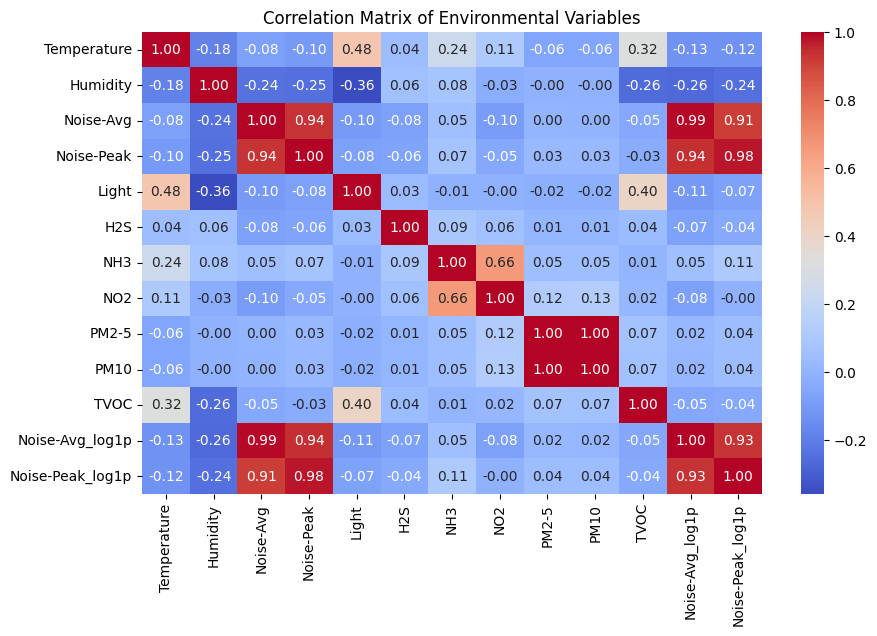

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix (numeric only)
corr_matrix = combined_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix of Environmental Variables")
plt.show()

5. Distribution Analysis

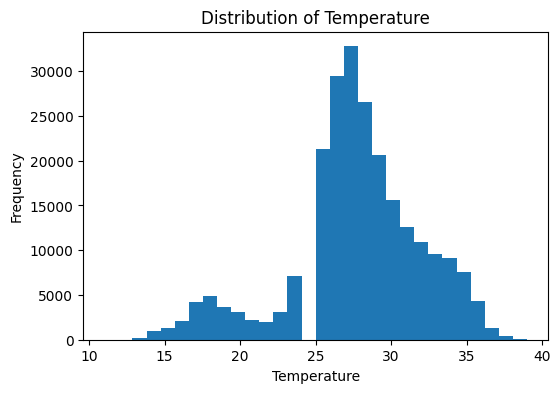

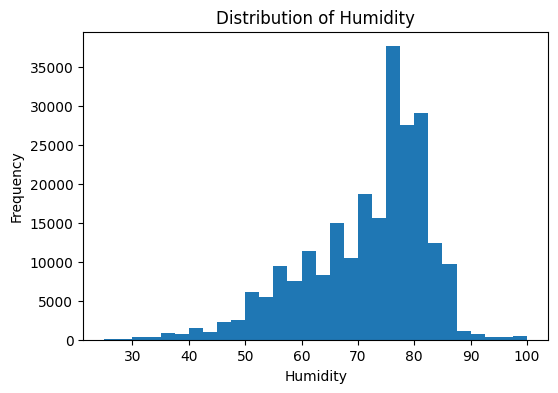

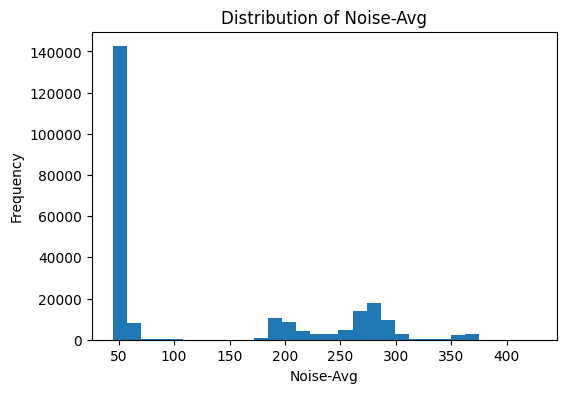

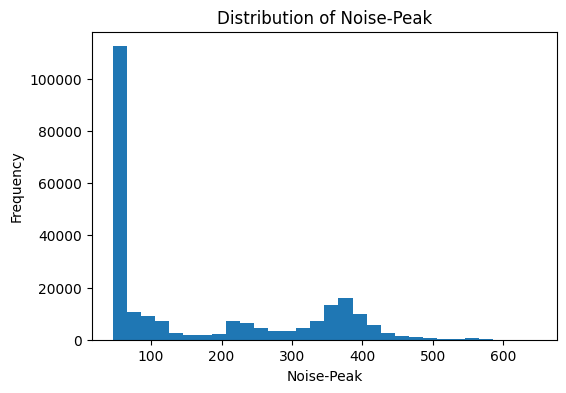

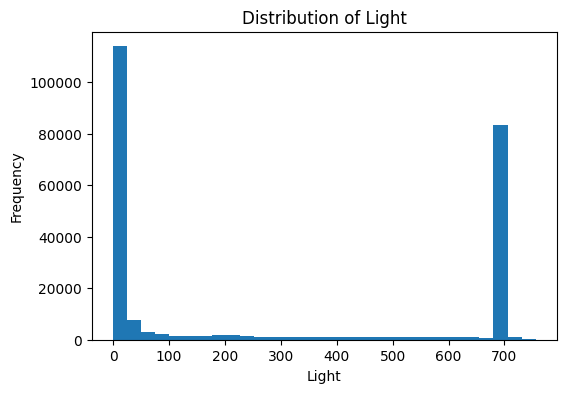

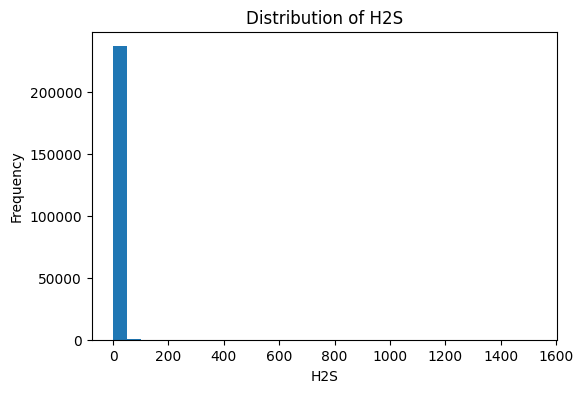

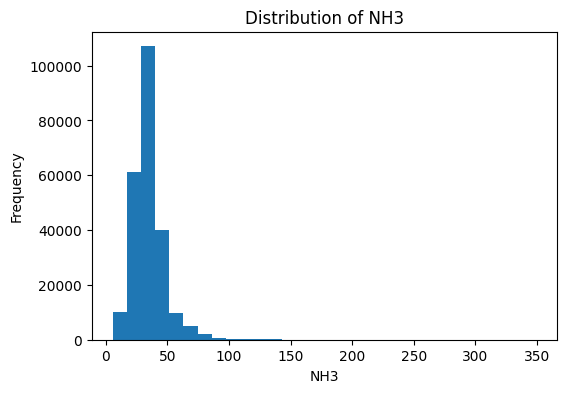

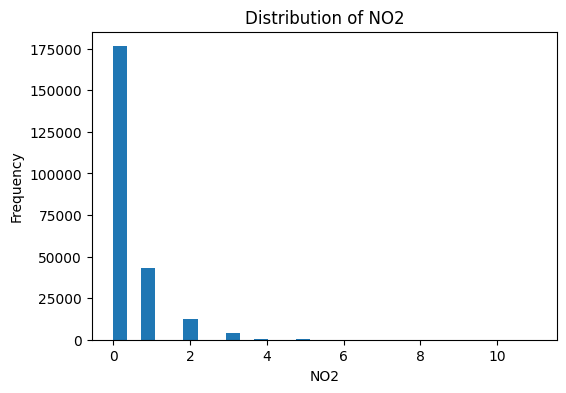

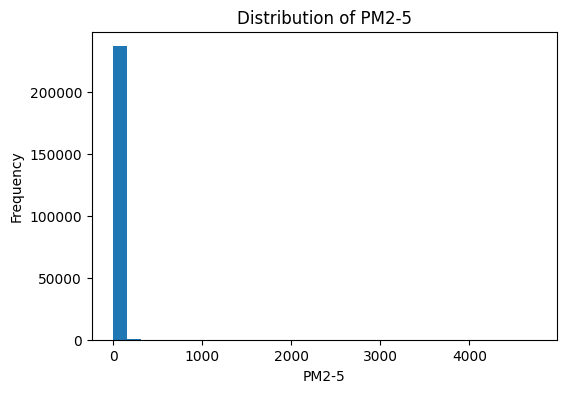

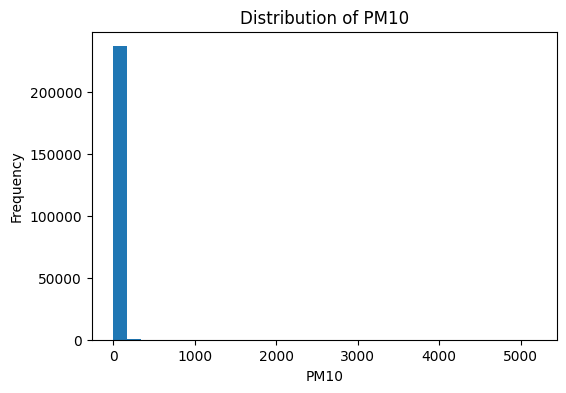

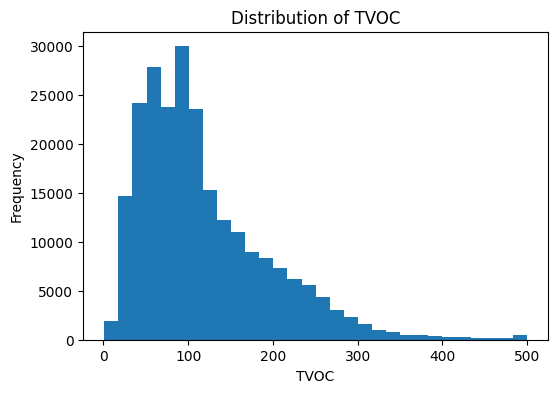

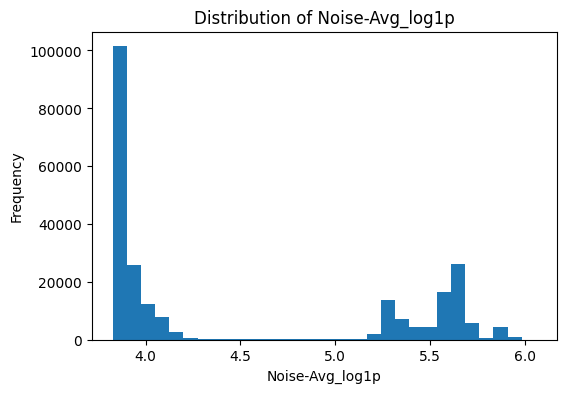

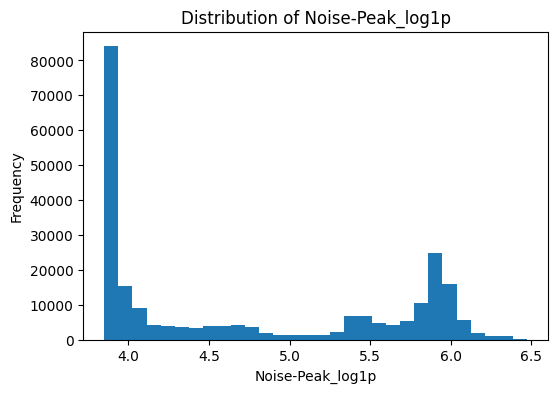

In [ ]:
numeric_cols = combined_df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(combined_df[col].dropna(), bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

6. Node-Based Comparison

In [ ]:
# Calculate average values per node
node_means = combined_df.groupby("Node").mean(numeric_only=True)

print("\nAverage values per node:")
display(node_means)


Average values per node:


,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC,Noise-Avg_log1p,Noise-Peak_log1p
Node,,,,,,,,,,,,,
Node 1 - Baby chick,28.735861,70.982793,193.680225,262.437559,295.305125,1.325821,39.066068,0.382114,7.394004,7.547982,114.594871,4.981102,5.302042
Node 2 - Main East,28.099059,75.552110,49.993149,71.287155,321.985879,2.181499,33.108483,0.401607,5.538303,5.645694,125.914733,3.928262,4.172637
Node 3 - Main West,26.096906,68.551970,114.752007,153.980609,273.133073,0.203427,32.791506,0.291402,7.949580,8.084897,116.797938,4.470525,4.652311


7. Visual Comparison Between Nodes

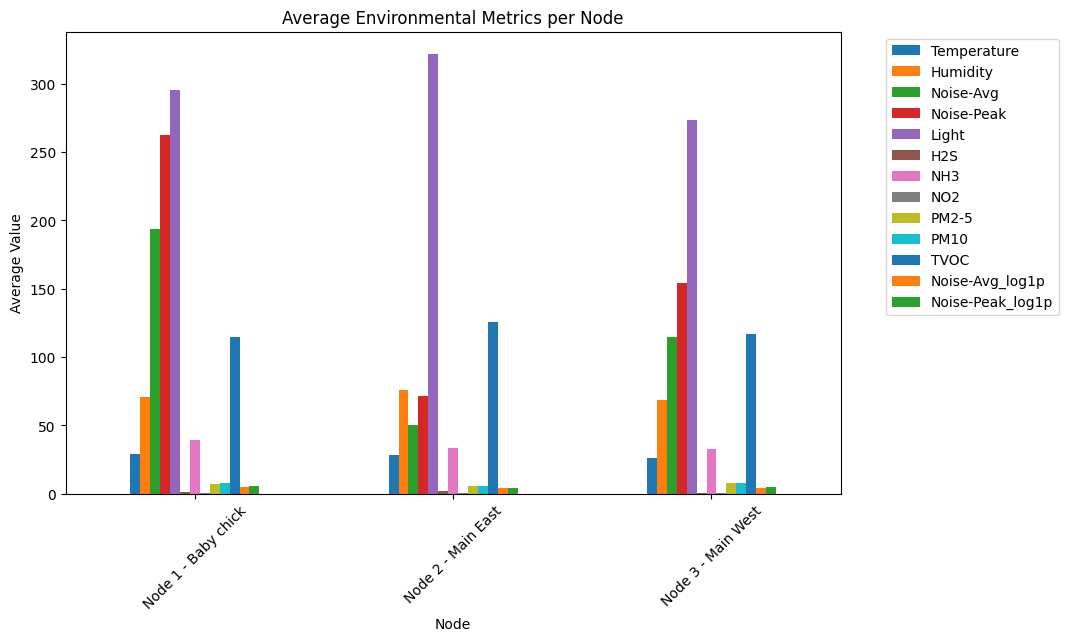

In [ ]:
node_means.plot(kind='bar', figsize=(10,6))

plt.title("Average Environmental Metrics per Node")
plt.xlabel("Node")
plt.ylabel("Average Value")

plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## Key Insights – Htoo Wunna Aung

- Strong correlations exist between pollution variables such as PM2.5 and PM10.
- Some environmental factors (e.g., temperature and humidity) show moderate relationships.
- Distribution plots indicate that several variables are skewed and may require normalization.
- Node comparison reveals differences in environmental conditions across monitoring locations.
- Certain nodes show consistently higher pollution levels, indicating possible environmental risk zones.

This analysis helps in understanding patterns in environmental data and supports further predictive modelling

8. Feature Selection

In [ ]:
# Drop non-numeric or irrelevant columns if needed
df_model = combined_df.select_dtypes(include=['float64', 'int64']).dropna()

print("Model dataset shape:", df_model.shape)
df_model.head()

Model dataset shape: (236970, 13)


,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC,Noise-Avg_log1p,Noise-Peak_log1p
0,23.0,45.0,50,77,407,1,106,3,7,7,102,3.931826,4.356709
1,13.0,69.0,49,119,4,0,59,4,90,93,98,3.912023,4.787492
2,13.0,69.0,46,49,3,0,59,3,3,3,102,3.850148,3.912023
3,13.0,68.0,46,50,10,0,59,2,0,0,99,3.850148,3.931826
4,13.0,68.0,46,48,13,0,58,2,0,0,100,3.850148,3.891820


9. Define Target Variable

In [ ]:
# predicting PM10
target_column = 'PM10'

X = df_model.drop(columns=[target_column])
y = df_model[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (236970, 12)
Target shape: (236970,)


10. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 189576
Testing samples: 47394


11. Train Model (Linear Regression)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


12. Predictions & Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Model Performance:
MAE: 0.41112653680339106
MSE: 2.1904362502472368
R² Score: 0.9954392930868662


13. Prediction vs Actual Plot

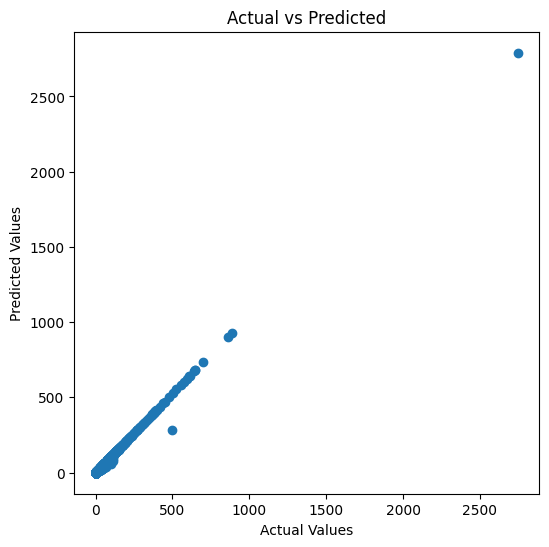

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

14. Boxplot for Outliers

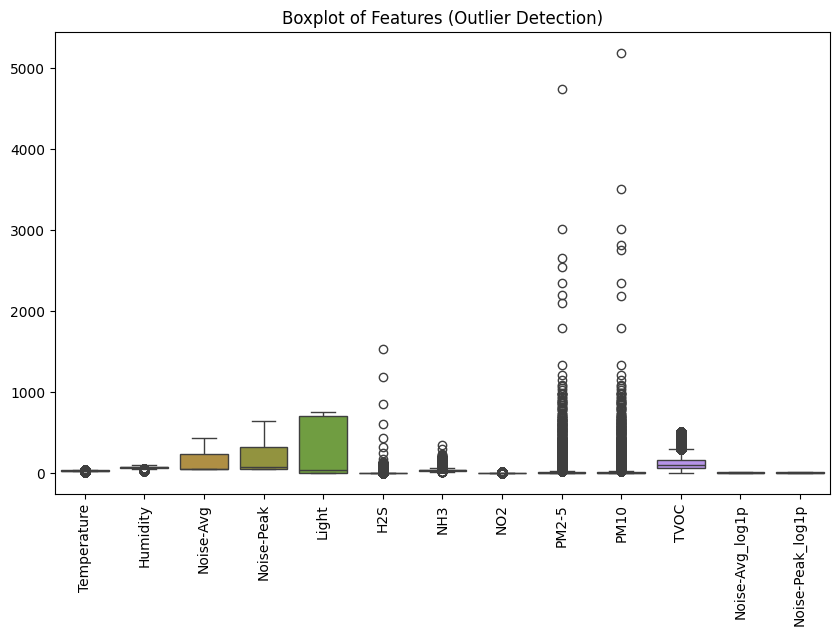

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df_model)

plt.xticks(rotation=90)
plt.title("Boxplot of Features (Outlier Detection)")

plt.show()

## Predictive Modelling Insights – Htoo Wunna Aung

- A Linear Regression model was used to predict environmental variables.
- The R² score indicates how well the model explains the data.
- Model errors (MAE, MSE) suggest the level of prediction accuracy.
- The scatter plot shows the relationship between actual and predicted values.
- Some variance suggests potential improvement using more advanced models.

This section demonstrates how environmental data can be used for predictive analysis.